In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path


In [ ]:
image_path = Path('.').parent / '/home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025_edited/map.pgm'
output_path = Path('.').parent / '../output'  
output_path.mkdir(exist_ok=True)

print(f"Processing {image_path}...")


## Load the image

In [ ]:
img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
if img is None:
    raise ValueError(f"Could not load image from {image_path}")
plt.imshow(img, cmap='gray')

In [ ]:
print(f"Loaded image with shape: {img.shape}")

# Threshold the image to create a binary image
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Invert if the track is white (assuming track is darker than background)
invert = False
if invert:
    binary = 255 - binary

In [ ]:
# Find contours - for boundary extraction
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
len(contours)

In [ ]:
# Find the largest contour on the track
largest_contour = max(contours, key=cv2.contourArea)
print("Largest contour has shape:", largest_contour.shape)

In [ ]:
boundary_points = largest_contour

# Extract coordinates for plotting
largest_contour_coords =    [(point[0][0], point[0][1]) for point in largest_contour] # type: ignore
boundary_coords =           [(point[0][0], point[0][1]) for point in boundary_points] # type: ignore

# Plot immediately
plt.figure(figsize=(8, 6))
plt.imshow(binary, cmap='gray')  # Show the binary image as background
# Plot raw largest contour
largest_x = [p[0] for p in largest_contour_coords]
largest_y = [p[1] for p in largest_contour_coords]
plt.plot(largest_x, largest_y, 'm-', linewidth=2, label='Largest Contour')

plt.title('Largest Contour and Simplified Boundary')
plt.legend()
plt.show()


In [ ]:

# Erode to create an artificial inner boundary
kernal_size = 2
kernel = np.ones((kernal_size, kernal_size), np.uint8)
iterations = 2
eroded = cv2.erode(binary, kernel, iterations=iterations)  # Adjust iterations as needed

# Extract all contours with hierarchy using RETR_CCOMP
contours, hierarchy = cv2.findContours(eroded, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)

# Find the contour with the smallest area
inner_contour = None
if contours:
    inner_contour = min(contours, key=cv2.contourArea)
    # Optionally filter out tiny noise contours
    contour_noise = 2
    if cv2.contourArea(inner_contour) < contour_noise:  # Adjust threshold as needed
        print("Smallest contour too small, might be noise.")
        inner_contour = None


In [ ]:
# --- Plot inner contour ---
if inner_contour is not None:
    # Reshape into (N,2) and split x/y
    pts = inner_contour.reshape(-1, 2)
    xs, ys = pts[:,0], pts[:,1]

    plt.figure(figsize=(8,6))
    plt.imshow(binary, cmap='gray')       # or plt.imshow(img, cmap='gray')
    plt.plot(xs, ys, 'r-', linewidth=2, label='Inner Contour')
    plt.legend()
    plt.title("Inner Contour Overlay")
    plt.axis('off')  # optional
    plt.show()
else:
    print("No valid inner contour to plot.")

In [ ]:
inner_contour  = inner_contour.reshape(-1, 2)  # type: ignore
inner_contour_coords = inner_contour
inner_contour_coords.shape

In [ ]:
import numpy as np
import cv2

midpoints = []

# Convert contours to NumPy arrays
inner_array = np.array(inner_contour_coords)
outer_array = np.array(largest_contour_coords)

def does_line_cross_contour(p1, p2, contour):
    """
    Check if the line segment (p1 -> p2) intersects the given contour.
    """
    for i in range(len(contour)):
        q1 = contour[i]
        q2 = contour[(i + 1) % len(contour)]  # Wrap around
        if cv2.clipLine((q1[0], q1[1], q2[0], q2[1]), p1, p2):
            return True  # Line crosses the contour
    return False

for inner_point in inner_contour_coords:
    # Compute distances
    distances = np.linalg.norm(outer_array - np.array(inner_point), axis=1)

    # Sort indices by distance
    sorted_indices = np.argsort(distances)

    # Find the closest valid outer point (not crossing the track)
    for closest_index in sorted_indices:
        outer_point = largest_contour_coords[closest_index]
        
        # Check if the midpoint crosses the inner contour (i.e., the "wall")
        if not does_line_cross_contour(inner_point, outer_point, inner_array):
            # Compute midpoint
            midpoint_x = (inner_point[0] + outer_point[0]) / 2
            midpoint_y = (inner_point[1] + outer_point[1]) / 2
            midpoint = (midpoint_x, midpoint_y)

            midpoints.append(midpoint)
            print(f"Midpoint between {inner_point} and {outer_point} is {midpoint}")
            break  # Found a valid point, move to the next inner point


In [ ]:
# Skeletonize to get centerline
# Distance transform + adaptive thresholding
dist_transform = cv2.distanceTransform(binary, cv2.DIST_L2, 5)

# Normalize for visualization
dist_norm = cv2.normalize(dist_transform, None, 0, 1.0, cv2.NORM_MINMAX) # type: ignore

# Improve skeleton by using an adaptive threshold based on max distance
max_dist = np.max(dist_transform[binary > 0])  # Max distance within track
factor = 0.5 ## Factor
thresh_value = max_dist * factor  # Threshold at half the max distance (adjustable)
_, skeleton = cv2.threshold(dist_transform, thresh_value, 255, cv2.THRESH_BINARY) # type: ignore
skeleton = skeleton.astype(np.uint8)

# Optional: Thin the skeleton with a single erosion step to refine it
kernel = np.ones((3, 3), np.uint8)
skeleton = cv2.erode(skeleton, kernel, iterations=1)

In [ ]:
# Visualize results

plt.figure(figsize=(12, 10))

# Result with coordinates
plt.imshow(img, cmap='gray')

boundary_x = [p[0] for p in boundary_coords]
boundary_y = [p[1] for p in boundary_coords]

# if inner_contour_coords:
inner_x = [p[0] for p in inner_contour_coords]
inner_y = [p[1] for p in inner_contour_coords]
plt.plot(inner_x, inner_y, 'r-', linewidth=2, label='Smallest Inner Contour (RETR_CCOMP)')

plt.plot(boundary_x, boundary_y, 'b-', linewidth=2, label='Boundary')
plt.title('Extracted Track Coordinates')
plt.legend()

plt.tight_layout()
plt.show()
if output_path:
    plt.savefig(output_path / 'track_with_coords.png')

## Adjust the Threshold Dynamically
Instead of a fixed max_dist * 0.5, try a lower or adaptive threshold to include more of the central region:


In [ ]:
dist_transform = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
max_dist = np.max(dist_transform[binary > 0])
thresh_value = max_dist * 0.3  # Try 0.3 or 0.2 to widen the skeleton initially
_, skeleton = cv2.threshold(dist_transform, thresh_value, 255, cv2.THRESH_BINARY)
skeleton = skeleton.astype(np.uint8)

# Optional: Thin it
try:
    import cv2
    skeleton = cv2.ximgproc.thinning(skeleton)  # Preferred if available
    print("Using OpenCV thinning.")
except ImportError:
    kernel = np.ones((3, 3), np.uint8)
    skeleton = cv2.erode(skeleton, kernel, iterations=1)

# Check result
plt.figure(figsize=(10, 8))
plt.imshow(binary, cmap='gray')
plt.imshow(skeleton, cmap='Reds', alpha=0.5)
plt.title('Adjusted Skeleton')
plt.show()
print(f"Skeleton pixels: {cv2.countNonZero(skeleton)}")

## Smooth the Binary Image First

If the track’s boundaries are jagged or uneven, smooth them before the distance transform:


In [ ]:
# Smooth binary to even out boundaries
binary_smoothed = cv2.GaussianBlur(binary, (5, 5), 0)
_, binary_smoothed = cv2.threshold(binary_smoothed, 127, 255, cv2.THRESH_BINARY)

plt.imshow(binary_smoothed)

In [ ]:
dist_transform = cv2.distanceTransform(binary_smoothed, cv2.DIST_L2, 5)
max_dist = np.max(dist_transform[binary_smoothed > 0])
thresh_value = max_dist * 0.4  # Middle ground
_, skeleton = cv2.threshold(dist_transform, thresh_value, 255, cv2.THRESH_BINARY) # type: ignore
skeleton = skeleton.astype(np.uint8)
plt.imshow(skeleton)

In [ ]:
# Thin it
try:
    skeleton = cv2.ximgproc.thinning(skeleton)
    print("Used ximgproc OpenCV thinning.")
except ImportError:
    print("Using basic thinning.")
    kernel = np.ones((3, 3), np.uint8)
    skeleton = cv2.erode(skeleton, kernel, iterations=1)
plt.imshow(skeleton)

In [ ]:
y_coords, x_coords = np.where(skeleton > 0)  # Get row (y) and column (x) indices
skeleton_points = np.array(list(zip(x_coords, y_coords)))  # Combine into (x, y) pairs

# Save if needed
if output_path:
    cv2.imwrite(str(output_path / 'smoothed_binary_skeleton.png'), skeleton)

# Visualize
plt.figure(figsize=(10, 8))
plt.imshow(binary_smoothed, cmap='gray')
plt.imshow(skeleton, cmap='Reds', alpha=0.5)
plt.title('Smoothed Binary with Skeleton')
plt.show()

## Use a completely different approach with a Medial Axis Transform

The Medial Axis Transform (MAT) is a skeletonization algorithm that is based on the distance transform. The MAT is a thinning algorithm that reduces the binary image to its skeleton. The skeleton is a set of lines that are equidistant to the edges of the binary image. The MAT is a powerful tool for shape analysis and pattern recognition.

In [ ]:
from skimage.morphology import  medial_axis
import numpy as np

# Convert binary to boolean (True for 255, False for 0)
binary_bool = binary > 0

# Medial axis transform (returns skeleton and distance)
skeleton, distance = medial_axis(binary_bool, return_distance=True)

# Convert back to uint8
skeleton = (skeleton * 255).astype(np.uint8)

# Visualize
plt.figure(figsize=(10, 8))
plt.imshow(binary, cmap='gray')
plt.imshow(skeleton, cmap='Reds', alpha=0.5)
plt.title('Medial Axis Skeleton')
plt.show()
print(f"Skeleton pixels: {cv2.countNonZero(skeleton)}")

y_coords, x_coords = np.where(skeleton > 0)  # Get row (y) and column (x) indices
skeleton_points = np.array(list(zip(x_coords, y_coords)))  # Combine into (x, y) pairs

# Save if needed
if output_path:
    cv2.imwrite(str(output_path / 'medial_axis_smoothed_skeleton.png'), skeleton)

# Start to make structured functions

In [28]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

In [29]:
image_path = Path('.').parent / '/home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025_edited/map.pgm'
output_path = Path('.').parent / '../output'  
output_path.mkdir(exist_ok=True)

print(f"Processing {image_path}...")

Processing /home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025_edited/map.pgm...


In [30]:
def load_binary_image(image_path: str, invert: bool) -> np.ndarray:
    """
    Load a binary image from the specified path.
    """
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not load image from {image_path}")
    print(f"Loaded image with shape: {img.shape}")

    # Threshold the image to create a binary image
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    # Invert if the track is white (assuming track is darker than background)
    invert = False
    if invert:
        binary = 255 - binary
    return binary

Loaded image with shape: (180, 235)


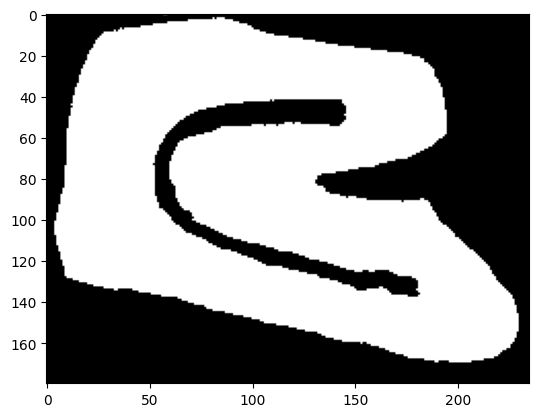

In [31]:
img = load_binary_image(image_path, invert=False)
plt.imshow(img, cmap='gray')

In [32]:
def find_outer_border(binary_image: cv2.typing.MatLike) -> cv2.typing.MatLike:
   contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

   # Find the largest contour on the track
   boundary_points = max(contours, key=cv2.contourArea)
   print("Largest contour has shape:", boundary_points.shape)

   # Extract coordinates for plotting
   boundary_coords =  [(point[0][0], point[0][1]) for point in boundary_points] # type: ignore
   return boundary_coords
    

Largest contour has shape: (323, 1, 2)


Text(0.5, 1.0, 'Outer Border')

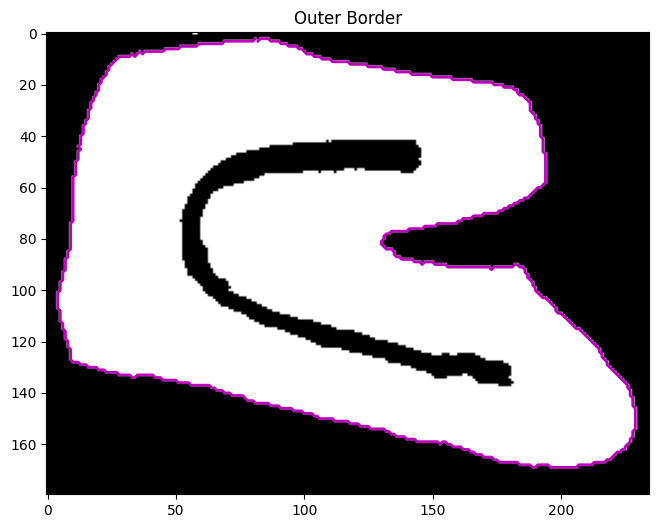

In [33]:
outer_border = find_outer_border(img)

# Plot immediately
plt.figure(figsize=(8, 6))
plt.imshow(img, cmap='gray')  # Show the binary image as background
# Plot raw largest contour
outer_x = [p[0] for p in outer_border]
outer_y = [p[1] for p in outer_border]
plt.plot(outer_x, outer_y, 'm-', linewidth=2, label='Outer Border')
plt.title('Outer Border')

In [34]:
def sample_waypoints(points: np.ndarray, num_points: int) -> np.ndarray:
    """
    Sample a specified number of waypoints evenly along a polyline defined by points.

    Args:
        points: An (N,2) array of (x,y) coordinates defining the path.
        num_points: Number of waypoints to sample.

    Returns:
        An (num_points,2) array of sampled (x,y) coordinates.
    """
    # Compute segment lengths
    diffs = np.diff(points, axis=0)
    seg_lengths = np.hypot(diffs[:,0], diffs[:,1])
    cumulative = np.concatenate(([0], np.cumsum(seg_lengths)))
    total_length = cumulative[-1]

    # Desired distances along the path
    distances = np.linspace(0, total_length, num_points)

    # Allocate output
    waypoints = np.zeros((num_points, 2), dtype=float)

    # Walk through segments to interpolate
    idx = 0
    for i, d in enumerate(distances):
        # Move idx to segment containing this distance
        while idx < len(cumulative)-2 and d > cumulative[idx+1]:
            idx += 1
        # Interpolate between points[idx] and points[idx+1]
        t = (d - cumulative[idx]) / (cumulative[idx+1] - cumulative[idx]) if cumulative[idx+1] > cumulative[idx] else 0
        waypoints[i] = (1 - t) * points[idx] + t * points[idx+1]
    return waypoints

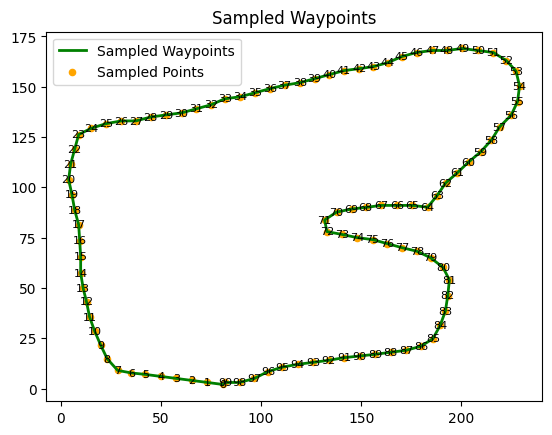

In [44]:
outer_waypoints = sample_waypoints(np.array(outer_border), 100)
# Plot sampled waypoints
plt.plot(outer_waypoints[:,0], outer_waypoints[:,1], 'g-', linewidth=2, label='Sampled Waypoints')
# Put actual scatter points to see them
plt.scatter(outer_waypoints[:,0], outer_waypoints[:,1], c='orange', s=20, label='Sampled Points')
# Add a text label to each waypoint
for i, (x, y) in enumerate(outer_waypoints):
    plt.text(x, y, str(i), fontsize=8, color='black', ha='center', va='center')
plt.title('Sampled Waypoints')
plt.legend()
plt.show()

In [53]:
def find_inner_border(binary_image: cv2.typing.MatLike) -> cv2.typing.MatLike:
    """
    Find the inner border of a binary image.
    
    Args:
        binary_image: Binary image
        
    Returns:
        Inner border contour as array of points
    """
    # Erode to create an artificial inner boundary
    kernal_size = 2
    kernel = np.ones((kernal_size, kernal_size), np.uint8)
    iterations = 2
    eroded = cv2.erode(binary_image, kernel, iterations=iterations)
    
    # Extract all contours with hierarchy using RETR_CCOMP
    contours, _ = cv2.findContours(eroded, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    
    # Find the contour with the smallest area
    inner_contour = None
    if contours:
        inner_contour = min(contours, key=cv2.contourArea)
        
        # Optionally filter out tiny noise contours
        contour_noise = 2
        if cv2.contourArea(inner_contour) < contour_noise:
            print("Smallest contour too small, might be noise.")
            inner_contour = None
    
    if inner_contour is not None:
        # Make sure the contour is closed
        if not np.array_equal(inner_contour[0], inner_contour[-1]):
            inner_contour = np.append(inner_contour, inner_contour[0:1], axis=0)
            
        return inner_contour.reshape(-1, 2)
    
    return np.array([])

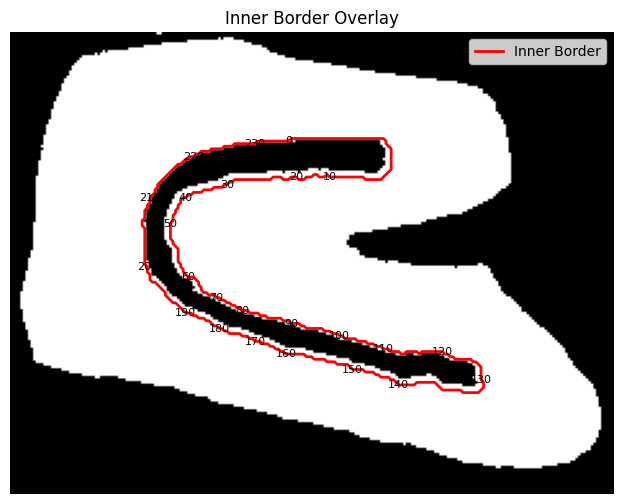

In [ ]:
inner_boarder = find_inner_border(img)
# Plot inner contour
if inner_boarder is not None:
    # Reshape into (N,2) and split x/y
    pts = inner_boarder.reshape(-1, 2)
    xs, ys = pts[:,0], pts[:,1]

    plt.figure(figsize=(8,6))
    plt.imshow(img, cmap='gray')       # or plt.imshow(img, cmap='gray')
    plt.plot(xs, ys, 'r-', linewidth=2, label='Inner Border')
    # Add a text label to each waypoint
    for i, (x, y) in enumerate(inner_boarder):
        if i % 5 == 0:
            plt.text(x, y, str(i), fontsize=8, color='black', ha='center', va='center')
    plt.legend()
    plt.title("Inner Border Overlay")
    plt.axis('off')  # optional
    plt.show()
else:
    print("No valid inner contour to plot.")

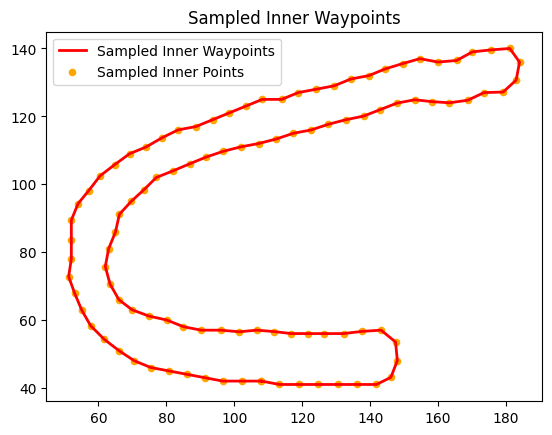

In [47]:
inner_waypoints = sample_waypoints(find_inner_border, 100)
# Plot sampled waypoints
plt.plot(inner_waypoints[:,0], inner_waypoints[:,1], 'r-', linewidth=2, label='Sampled Inner Waypoints')
# Put actual scatter points to see them
plt.scatter(inner_waypoints[:,0], inner_waypoints[:,1], c='orange', s=20, label='Sampled Inner Points')
plt.title('Sampled Inner Waypoints')
plt.legend()
plt.show()

In [39]:
len(inner_waypoints), len(outer_waypoints)

(100, 100)

In [40]:
def get_centerline(outer_waypoints: np.ndarray, inner_waypoints: np.ndarray) -> np.ndarray:
    """
    Compute the centerline between two sets of waypoints.
    """
    # Ensure both arrays are of the same length
    if len(outer_waypoints) != len(inner_waypoints):
        raise ValueError("Outer and inner waypoints must have the same length.")

    # Compute midpoints
    midpoints = (outer_waypoints + inner_waypoints) / 2
    return midpoints

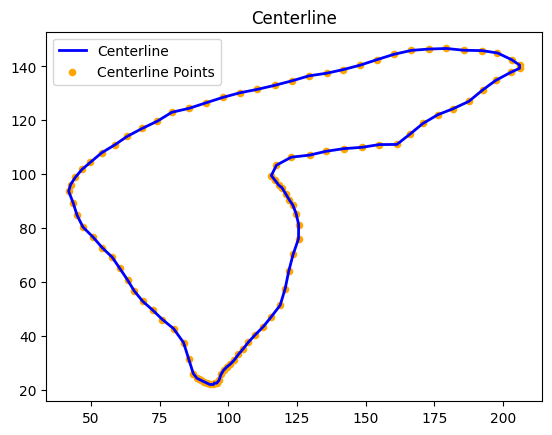

In [42]:
center_line = get_centerline(outer_waypoints, inner_waypoints)
# Plot centerline
plt.plot(center_line[:,0], center_line[:,1], 'b-', linewidth=2, label='Centerline')
# Put actual scatter points to see them
plt.scatter(center_line[:,0], center_line[:,1], c='orange', s=20, label='Centerline Points')
plt.title('Centerline')
plt.legend()
plt.show()


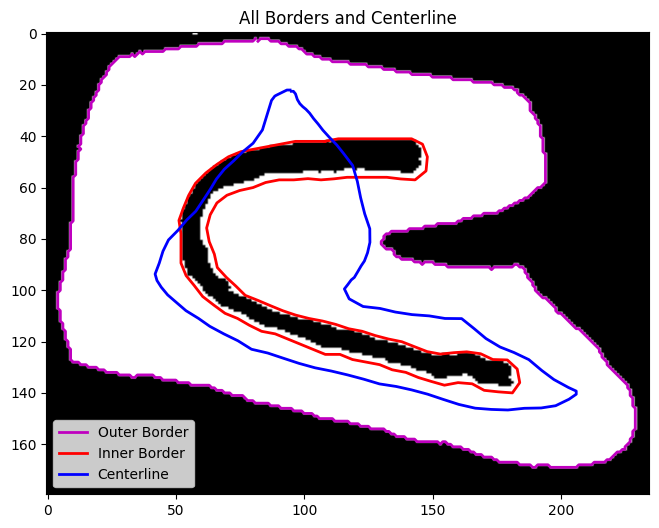

In [43]:
# show all lines together
plt.figure(figsize=(8, 6))
plt.imshow(img, cmap='gray')  # Show the binary image as background
# Plot outer border
outer_x = [p[0] for p in outer_border]
outer_y = [p[1] for p in outer_border]
plt.plot(outer_x, outer_y, 'm-', linewidth=2, label='Outer Border')
# Plot inner border
inner_x = [p[0] for p in inner_waypoints]   
inner_y = [p[1] for p in inner_waypoints]
plt.plot(inner_x, inner_y, 'r-', linewidth=2, label='Inner Border')
# Plot centerline
center_x = [p[0] for p in center_line]
center_y = [p[1] for p in center_line]
plt.plot(center_x, center_y, 'b-', linewidth=2, label='Centerline')
plt.title('All Borders and Centerline')
plt.legend()
plt.show()

In [22]:
import numpy as np

from pathlib import Path
from skimage.morphology import medial_axis
import csv

def extract_track(
    image_path: str,
    resolution: float,
    invert: bool = False,
    output_dir: str = "../tmp"
) -> None:
    """
    Process a track image to extract outer boundary, inner boundary, and centerline.

    Args:
        image_path: Path to the input image (grayscale or color).
        resolution: Scaling factor to convert pixel coords to real-world units.
        invert: If True, invert binary image (useful when track is light on dark).
        output_dir: Directory to save output CSVs.
    """
    # Prepare paths
    img_p = Path(image_path)
    out_p = Path(output_dir)
    out_p.mkdir(exist_ok=True, parents=True)

    # Load image in grayscale
    img = cv2.imread(str(img_p), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Cannot load image: {img_p}")

    # Threshold to binary
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    if invert:
        binary = 255 - binary

    # Find external contours
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        raise RuntimeError("No contours found in image.")

    # Outer boundary: largest contour
    outer = max(contours, key=cv2.contourArea).reshape(-1, 2)

    # Inner boundary: erode and find smallest contour
    kernel = np.ones((3, 3), np.uint8)
    eroded = cv2.erode(binary, kernel, iterations=3)
    contours_i, _ = cv2.findContours(eroded, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    inner = None
    if contours_i:
        candidate = min(contours_i, key=cv2.contourArea).reshape(-1, 2)
        if cv2.contourArea(candidate) >= 50:
            inner = candidate
    if inner is None:
        raise RuntimeError("Inner contour not found or too small.")

    # Centerline via Medial Axis Transform
    binary_bool = binary > 0
    skeleton_bool, _ = medial_axis(binary_bool, return_distance=True)
    skeleton_pts = np.column_stack(np.where(skeleton_bool))[:, ::-1]  # x,y order

    # Scale coordinates by resolution
    outer_scaled = outer * resolution
    inner_scaled = inner * resolution
    center_scaled = skeleton_pts * resolution

    # Define save helper
    def save_csv(points: np.ndarray, fname: str):
        file = out_p / fname
        with open(file, 'w', newline='') as f:
            w = csv.writer(f)
            w.writerow(['x', 'y'])
            for x, y in points:
                w.writerow([x, y])

    # Save files
    save_csv(outer_scaled, 'outer_boundary.csv')
    save_csv(inner_scaled, 'inner_boundary.csv')
    save_csv(center_scaled, 'centerline.csv')

    print(f"Saved outer boundary: {out_p/'outer_boundary.csv'}")
    print(f"Saved inner boundary: {out_p/'inner_boundary.csv'}")
    print(f"Saved centerline: {out_p/'centerline.csv'}")


# Example usage:
# extract_track('path/to/map.pgm', resolution=0.5, invert=True, output_dir='output')


In [23]:
extract_track(
    image_path=str(image_path),
    resolution=0.5,  # Adjust as needed
    invert=True,
    output_dir=str(output_path)
)

RuntimeError: Inner contour not found or too small.